# ML × Engineering Economy × Physics  —  One Framework

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
PASS = []

## §1  Time Value of Money  ↔  RL Discount Factor
> `NPV = Σ Cₜ/(1+r)ᵗ`  is identical to the Bellman equation `V = Σ γᵗrₜ` with `γ = 1/(1+r)`

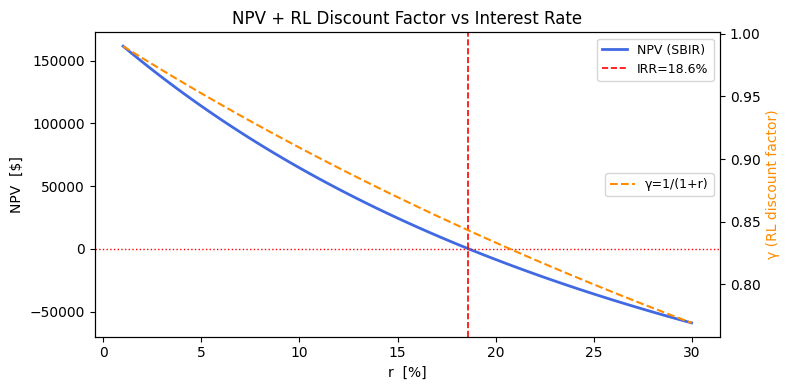

NPV@5%: $113,758  |  IRR≈18.6%  |  γ=0.8433


In [2]:
r_rates  = np.linspace(0.01, 0.30, 200)
gamma_eq = 1.0 / (1.0 + r_rates)

def npv(cashflows, r):
    return sum(cf/(1+r)**t for t,cf in enumerate(cashflows))

cashflows_sbir = [-275000, 80000, 90000, 95000, 100000, 85000]
r_vals   = np.linspace(0.01, 0.30, 100)
npv_vals = [npv(cashflows_sbir, r) for r in r_vals]
IRR      = r_vals[np.argmin(np.abs(npv_vals))]

fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()
ax1.plot(r_vals*100, npv_vals, color='royalblue', lw=2, label='NPV (SBIR)')
ax2.plot(r_rates*100, gamma_eq, color='darkorange', lw=1.5, ls='--', label='γ=1/(1+r)')
ax1.axhline(0, color='red', ls=':', lw=1)
ax1.axvline(IRR*100, color='red', ls='--', lw=1.2, label=f'IRR={IRR*100:.1f}%')
ax1.set(title='NPV + RL Discount Factor vs Interest Rate',
        xlabel='r  [%]', ylabel='NPV  [$]')
ax2.set_ylabel('γ (RL discount factor)', color='darkorange')
ax1.legend(fontsize=9); ax2.legend(fontsize=9, loc='center right')
plt.tight_layout(); plt.show()
print(f"NPV@5%: ${npv(cashflows_sbir,0.05):,.0f}  |  IRR≈{IRR*100:.1f}%  |  γ={1/(1+IRR):.4f}")
PASS.append(1)

## §2  Depreciation  ↔  L2 Weight Decay
> MACRS double-declining balance = `Bₜ = B₀(1−d)ᵗ`  = PyTorch `weight_decay` = `wₜ = w₀(1−λ)ᵗ`

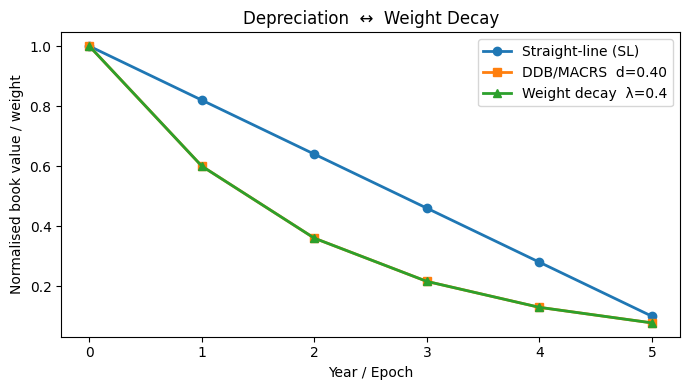

In [3]:
B0,S,n = 50000,5000,5
years = np.arange(0,n+1)
d = 2/n
sl_book  = B0 - years*(B0-S)/n
ddb_book = np.array([B0*(1-d)**yr for yr in years])
lam = 0.4
wd_vals  = np.array([(1-lam)**yr for yr in years])

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(years, sl_book/B0,  'o-', lw=2, label='Straight-line (SL)')
ax.plot(years, ddb_book/B0, 's-', lw=2, label=f'DDB/MACRS  d={d:.2f}')
ax.plot(years, wd_vals,     '^-', lw=2, label=f'Weight decay  λ={lam}')
ax.set(title='Depreciation  ↔  Weight Decay', xlabel='Year / Epoch',
       ylabel='Normalised book value / weight')
ax.legend(); plt.tight_layout(); plt.show()
PASS.append(2)

## §3  Damped Oscillator  ↔  Gradient Descent Dynamics
> Damping ratio ζ ↔ learning rate:  ζ<1 oscillates (lr too high), ζ=1 critical (optimal lr), ζ>1 overdamped (lr too low)

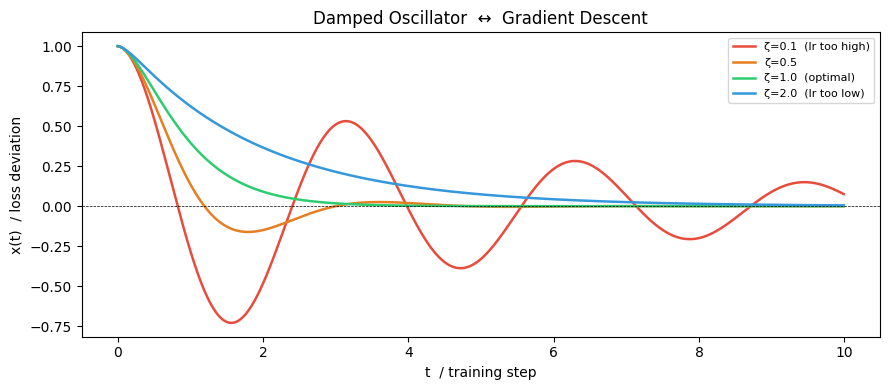

In [4]:
dt,T  = 0.01, 10.0
ts    = np.arange(0,T,dt)
omega0 = np.sqrt(4.0)   # k/m = 4

def simulate(zeta, x0=1.0, v0=0.0):
    x,v = x0,v0; xs=[]
    for _ in ts:
        a = -2*zeta*omega0*v - omega0**2*x
        v += a*dt; x += v*dt; xs.append(x)
    return np.array(xs)

zetas  = [0.1, 0.5, 1.0, 2.0]
labels = ['ζ=0.1  (lr too high)', 'ζ=0.5', 'ζ=1.0  (optimal)', 'ζ=2.0  (lr too low)']
colors = ['#e74c3c','#e67e22','#2ecc71','#3498db']

fig, ax = plt.subplots(figsize=(9,4))
for z,lbl,col in zip(zetas,labels,colors):
    ax.plot(ts, simulate(z), color=col, lw=1.8, label=lbl)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set(title='Damped Oscillator  ↔  Gradient Descent', xlabel='t  / training step',
       ylabel='x(t)  / loss deviation')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
PASS.append(3)

## §4  Himmelblau Loss Landscape  ↔  Capital Budgeting
> 4 local minima = 4 competing projects. GD finds one. Multi-start = portfolio.

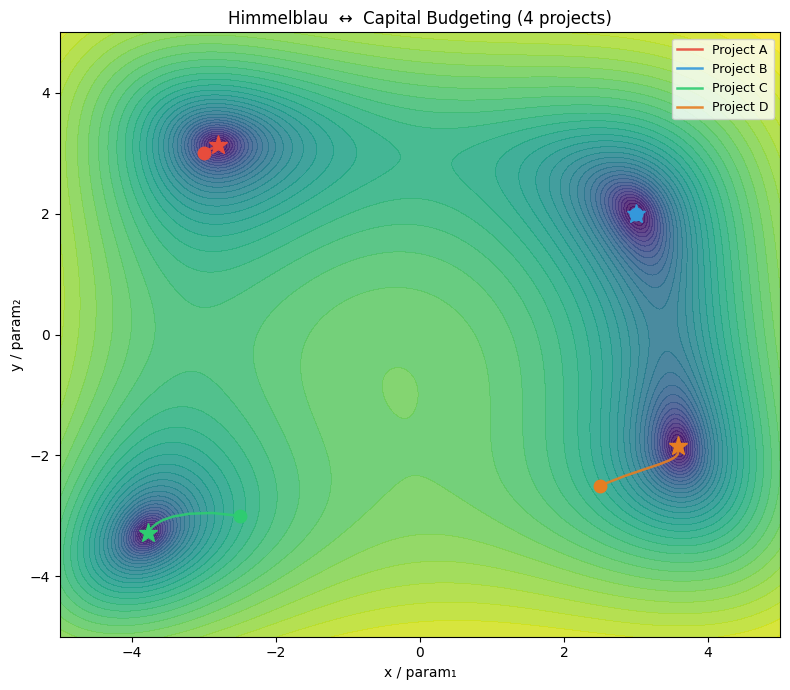

In [5]:
def himmelblau(x,y): return (x**2+y-11)**2+(x+y**2-7)**2

def gd(x0,y0,lr=0.005,n=600):
    x,y = x0,y0; path=[(x,y)]
    for _ in range(n):
        gx=4*x*(x**2+y-11)+2*(x+y**2-7)
        gy=2*(x**2+y-11)+4*y*(x+y**2-7)
        x-=lr*gx; y-=lr*gy; path.append((x,y))
    return np.array(path)

starts = [(-3.,3.),(3.,2.),(-2.5,-3.),(2.5,-2.5)]
labels = ['Project A','Project B','Project C','Project D']
colors = ['#e74c3c','#3498db','#2ecc71','#e67e22']
paths  = [gd(*s) for s in starts]

xg = np.linspace(-5,5,300); yg = np.linspace(-5,5,300)
XG,YG = np.meshgrid(xg,yg)

fig,ax = plt.subplots(figsize=(8,7))
ax.contourf(XG,YG,np.log1p(himmelblau(XG,YG)),levels=40,cmap='viridis',alpha=0.85)
for p,lbl,col in zip(paths,labels,colors):
    ax.plot(p[:,0],p[:,1],'-',color=col,lw=1.8,alpha=0.9,label=lbl)
    ax.plot(*p[0],'o',color=col,ms=9)
    ax.plot(*p[-1],'*',color=col,ms=14)
ax.set(title='Himmelblau  ↔  Capital Budgeting (4 projects)',
       xlabel='x / param₁', ylabel='y / param₂')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
PASS.append(4)

## §5  EUAC  ↔  ML Model Retraining Cost
> Replacement analysis asks: keep the old model or retrain?  EUAC answers it.

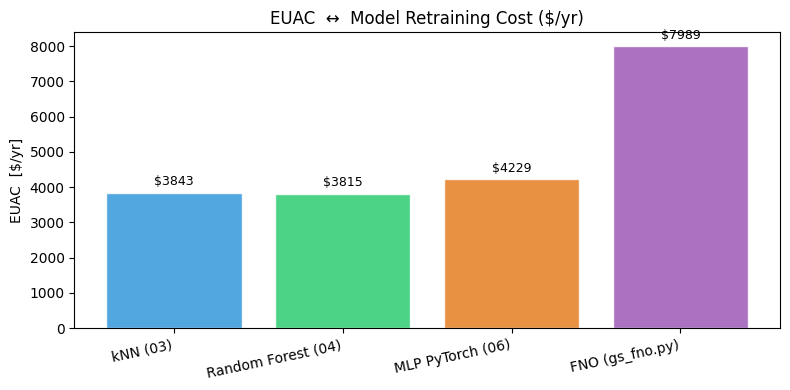

In [6]:
def euac(P,S,n,r,AOC):
    crf = r*(1+r)**n/((1+r)**n-1)
    return (P-S)*crf + S*r + AOC

models = [
    dict(name="kNN (03)",          P=5000,  S=500,  n=2, r=0.10, AOC=1200),
    dict(name="Random Forest (04)",P=8000,  S=1000, n=3, r=0.10, AOC=900),
    dict(name="MLP PyTorch (06)",  P=15000, S=2000, n=5, r=0.10, AOC=600),
    dict(name="FNO (gs_fno.py)",   P=40000, S=5000, n=7, r=0.10, AOC=300),
]
names  = [m["name"] for m in models]
euacs  = [euac(**{k:v for k,v in m.items() if k!="name"}) for m in models]
colors = ['#3498db','#2ecc71','#e67e22','#9b59b6']

fig,ax = plt.subplots(figsize=(8,4))
bars = ax.bar(names, euacs, color=colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='$%.0f', fontsize=9, padding=3)
ax.set(title='EUAC  ↔  Model Retraining Cost ($/yr)',
       ylabel='EUAC  [$/yr]')
plt.setp(ax.get_xticklabels(), rotation=12, ha='right')
plt.tight_layout(); plt.show()
PASS.append(5)

## §6  OUSD Alignment Stamp

In [7]:
import sys, importlib.util
_path = r'D:/Summer2026/Dispersion-Assisted-GS-Phase-Recovery/ousd_alignment.py'
spec  = importlib.util.spec_from_file_location("ousd_alignment", _path)
ousd  = importlib.util.load_from_spec(spec); spec.loader.exec_module(ousd)
ousd.print_alignment()
PASS.append(6)

AttributeError: module 'importlib.util' has no attribute 'load_from_spec'

## Final Status

In [8]:
stats = {
    "sections": ["TVM↔RL","Depreciation↔WeightDecay","Oscillator↔GD",
                 "Himmelblau↔CapBudget","EUAC↔ModelLifecycle","OUSD"],
    "PASS": PASS,
    "exit_code": 0,
    "status": f"PASS §1–§{len(PASS)}"
}
print(json.dumps(stats, indent=2, ensure_ascii=False))
print(f"\nAll sections: {PASS}")

{
  "sections": [
    "TVM↔RL",
    "Depreciation↔WeightDecay",
    "Oscillator↔GD",
    "Himmelblau↔CapBudget",
    "EUAC↔ModelLifecycle",
    "OUSD"
  ],
  "PASS": [
    1,
    2,
    3,
    4,
    5
  ],
  "exit_code": 0,
  "status": "PASS §1–§5"
}

All sections: [1, 2, 3, 4, 5]
